# POC Model
- Initial stock ranking model within-portfolio

## Things to Test
- Which response variable and model structure?
    - Structure
        - Simple saturated model with 1 Train and Test (Up to 2024, 2024 to present)
    - Types
        - Quantile rank model
        - Lambda rank model
        - Regression Model (_tweedie or weighted MSE_)
- CV Structure
    - Test purged and embargoed 3/4/5-Fold Cross Validation
    - Compare errors and generalization vs. simple Train/Test

- Variable Selection
    - Based on SHAP and temporal signal consistency

In [51]:
# %pip install matplotlib
# %pip install xgboost==3.0.2

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

In [79]:
def backtest_monthly_dollar(
    test_df,
    pred_col="pred",
    long_class=None,
    top_pct=None,
    price_col="close",
    initial_capital=10000,
    transaction_cost_bps=10,  # 10 basis points per trade
    monthly_contribution=0, 
    short_term_tax_rate=0.35
):
    """
    Realistic monthly rebalance backtest with:
    - Dollar tracking
    - Fractional shares
    - Transaction costs
    - Optional monthly capital injection
    """

    if long_class is None and top_pct is None:
        raise ValueError("Must specify either long_class or top_pct")

    df = test_df.copy()
    df = df.sort_values("date")
    df["year_month"] = df["date"].dt.to_period("M")

    capital = initial_capital
    portfolio_value_history = []
    turnover_history = []

    months = df["year_month"].unique()

    for i, month in enumerate(months):

        month_data = df[df["year_month"] == month]
        month_dates = month_data["date"].sort_values()
        first_date, last_date = month_dates.iloc[0], month_dates.iloc[-1]

        first_day = month_data[month_data["date"] == first_date]
        last_day = month_data[month_data["date"] == last_date]

        # --- Inject capital ---
        if i > 0:
            capital += monthly_contribution

        # --- Select portfolio ---
        if long_class is not None:
            selected = first_day[first_day[pred_col] == long_class]
        else:
            cutoff = first_day[pred_col].quantile(1 - top_pct)
            selected = first_day[first_day[pred_col] >= cutoff]

        tickers = selected["ticker"].unique()

        if len(tickers) == 0:
            portfolio_value_history.append(capital)
            turnover_history.append(0)
            continue

        weight = 1 / len(tickers)

        # --- Allocate capital equally ---
        allocations = {}
        shares = {}
        start_prices = {}

        for ticker in tickers:
            price = first_day[first_day["ticker"] == ticker][price_col].values[0]
            alloc = capital * weight
            share_qty = alloc / price

            allocations[ticker] = alloc
            shares[ticker] = share_qty
            start_prices[ticker] = price

        # --- Compute end-of-month value ---
        end_value = 0
        for ticker in tickers:
            if ticker in last_day["ticker"].values:
                end_price = last_day[last_day["ticker"] == ticker][price_col].values[0]
                end_value += shares[ticker] * end_price

        # --- Transaction Costs ---
        # Assume full turnover each rebalance (sell old, buy new)
        turnover = capital
        cost = turnover * (transaction_cost_bps / 10000)
        end_value -= cost

        gross_profit = end_value - capital

        if gross_profit > 0:
            tax = gross_profit * short_term_tax_rate
        else:
            tax = 0  # Optional: allow tax loss harvesting here

        capital = end_value - tax


        portfolio_value_history.append(capital)
        turnover_history.append(turnover)

    results = pd.DataFrame({
        "month": months,
        "portfolio_value": portfolio_value_history,
        "turnover": turnover_history
    })

    results["monthly_return"] = results["portfolio_value"].pct_change().fillna(0)
    results["cumulative_return"] = results["portfolio_value"] / initial_capital - 1

    print("\n=== Portfolio Summary ===")
    print(f"Final Portfolio Value: ${results['portfolio_value'].iloc[-1]:,.2f}")
    print(f"Cumulative Return: {results['cumulative_return'].iloc[-1]:.2%}")
    print(f"Annualized Return: {(results['monthly_return'].mean() * 12):.2%}")
    print(f"Sharpe Ratio: {(results['monthly_return'].mean() / results['monthly_return'].std() * np.sqrt(12)):.2f}")

    return results


In [35]:
df = pd.read_parquet('../data/processed/modeling_dataset_28d.parquet')

In [36]:
fred_features = [
    'sector', 'industry', 'DFF', 'DGS10', 'DGS2', 'T10Y2Y', 'CPIAUCSL',
    'CPILFESL', 'PCEPI', 'GDP', 'GDPC1', 'INDPRO', 'UNRATE', 'PAYEMS',
    'ICSA', 'UMCSENT', 'RSXFS', 'VIXCLS', 'DCOILWTICO', 'M2SL', 'TOTALSL'
]

rank_features = [col for col in df.columns if "rank" in col]

zscore_features = [col for col in df.columns if col.endswith('_zscore')]

quintile_features = [col for col in df.columns if col.endswith('_quintile')]


In [37]:
modeling_features = fred_features + rank_features + zscore_features + quintile_features

In [38]:
modeling_features

['sector',
 'industry',
 'DFF',
 'DGS10',
 'DGS2',
 'T10Y2Y',
 'CPIAUCSL',
 'CPILFESL',
 'PCEPI',
 'GDP',
 'GDPC1',
 'INDPRO',
 'UNRATE',
 'PAYEMS',
 'ICSA',
 'UMCSENT',
 'RSXFS',
 'VIXCLS',
 'DCOILWTICO',
 'M2SL',
 'TOTALSL',
 'open_rank',
 'high_rank',
 'low_rank',
 'close_rank',
 'volume_rank',
 'market_cap_rank',
 'enterprise_value_rank',
 'trailing_pe_rank',
 'forward_pe_rank',
 'peg_ratio_rank',
 'price_to_book_rank',
 'price_to_sales_rank',
 'enterprise_to_revenue_rank',
 'enterprise_to_ebitda_rank',
 'profit_margin_rank',
 'operating_margin_rank',
 'gross_margin_rank',
 'roe_rank',
 'roa_rank',
 'revenue_growth_rank',
 'earnings_growth_rank',
 'total_cash_rank',
 'total_debt_rank',
 'debt_to_equity_rank',
 'current_ratio_rank',
 'quick_ratio_rank',
 'book_value_rank',
 'revenue_per_share_rank',
 'earnings_per_share_rank',
 'dividend_rate_rank',
 'dividend_yield_rank',
 'payout_ratio_rank',
 'beta_rank',
 'shares_outstanding_rank',
 'float_shares_rank',
 'held_percent_insiders_r

### Generate train, test, and quintile target

In [47]:
target = "target_28d"

df = df[df[target].notna()].copy()

# Convert categorical columns to category dtype
categorical_features = ['sector', 'industry']
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Time-based split (1-month embargo for test)
train = df[df['date'] < '2024-01-01']
test = df[df['date'] >= '2024-02-01']

## 1) Quantile Rank: will a stock be in top 20% of returns?

In [12]:
# XGBoost classifier
base_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    n_estimators=50,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    random_state=42
)

base_model.fit(
    train[modeling_features],
    train[target]
)

test['pred'] = base_model.predict(test[modeling_features])



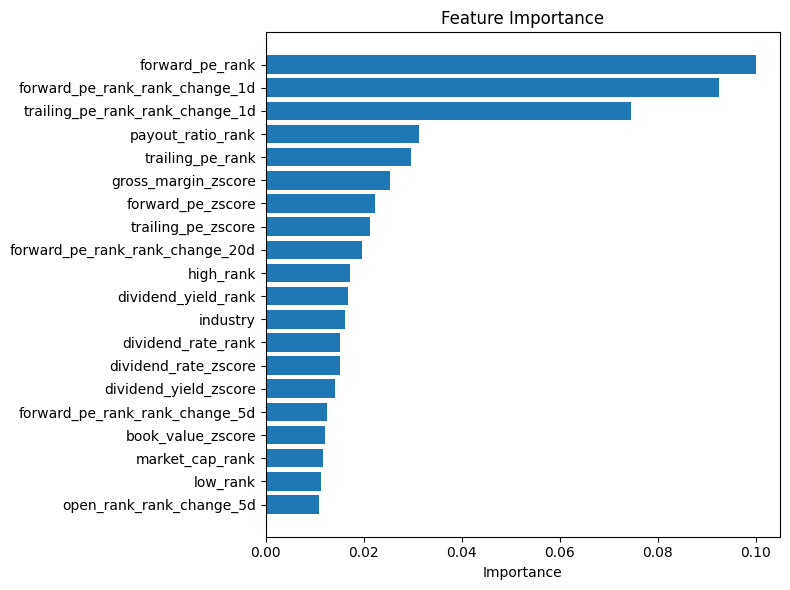

In [53]:
def plot_feature_importance(model, features, top_n=20, title="Feature Importance"):
    """Plot horizontal bar chart of top feature importances."""
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(top_n)

    importance_df = importance_df.sort_values("importance", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_feature_importance(base_model, modeling_features)

### Evaluate performance when rebalancing stocks monthly

In [80]:
backtest_monthly_rebalance(
        test, 
        pred_col="pred", 
        long_class=4, 
        top_pct=None, 
        price_col="close"
)


KeyError: 'pred'

## 2) Lambda Rank Model

In [ ]:
# Sort train and test by date to create groups
train = train.sort_values("date").reset_index(drop=True)
test = test.sort_values("date").reset_index(drop=True)

In [49]:
y_train = train["return_t+28"]
X_train = train[modeling_features]

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)

# Number of stocks per date
group_train = train.groupby("date").size().values
dtrain.set_group(group_train)

In [ ]:
# XGBoost Rank model
params = {
    "objective": "rank:pairwise",
    "eval_metric": "ndcg",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "colsample_bylevel": 0.8,
    "tree_method": "hist",
    "seed": 42
}

rank_model = xgb.train(
    params,
    dtrain,
    num_boost_round=50
)

# Make predictions on test set
y_test = test["return_t+28"]
X_test = test[modeling_features]
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)
test['pred_rank'] = rank_model.predict(dtest)

In [ ]:
backtest_monthly_dollar(
        test, 
        pred_col="pred_rank", 
        long_class=None, 
        top_pct=0.10, 
        price_col="close", 
        transaction_cost_bps=20, 
        initial_capital=10_000, 
        short_term_tax_rate=0.35
        # monthly_contribution=1000
)



=== Portfolio Summary ===
Final Portfolio Value: $13,869.90
Cumulative Return: 38.70%
Annualized Return: 29.05%
Sharpe Ratio: 2.15


,month,portfolio_value,turnover,monthly_return,cumulative_return
0,2024-02,10739.300450,10000.000000,0.000000,0.073930
1,2024-03,11025.403553,10739.300450,0.026641,0.102540
2,2024-04,10558.839507,11025.403553,-0.042317,0.055884
3,2024-05,11074.477169,10558.839507,0.048835,0.107448
4,2024-06,11276.512205,11074.477169,0.018243,0.127651
5,2024-07,11566.007266,11276.512205,0.025672,0.156601
6,2024-08,11872.960225,11566.007266,0.026539,0.187296
7,2024-09,12593.212336,11872.960225,0.060663,0.259321
8,2024-10,13015.939626,12593.212336,0.033568,0.301594
9,2024-11,14282.918941,13015.939626,0.097341,0.428292


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

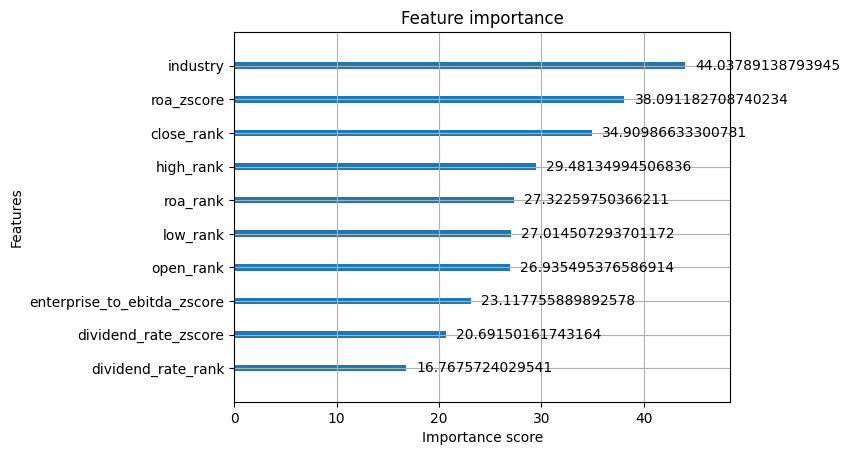

In [82]:
xgb.plot_importance(rank_model, importance_type='gain', max_num_features=10)
